In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## import

In [ ]:
sim_games_data_df = pd.json_normalize(
    pd.read_json('simulation_results/1cdd591f_macau_simulation.json', lines=True).to_dict(orient='records')
)
sim_games_results_df = pd.read_json('simulation_results/1cdd591f_macau_simulation_results.json', lines=True)

In [ ]:
sim_games_data_df.head()

,game_id,move_num,player,hand_size_before,top_card_before,effect_active,cards_in_hand_after,top_card_after,deck_remaining,action_made.action,action_made.card
0,0,1,0,5,10 Spades,False,4,5 Spades,32,play_card,5 Spades
1,0,2,1,5,5 Spades,False,6,5 Spades,31,draw_card,NaN
2,0,3,2,5,5 Spades,False,4,8 Spades,31,play_card,8 Spades
3,0,4,0,4,8 Spades,False,3,Q Clubs,31,skip,Q Clubs
4,0,5,1,6,Q Clubs,False,5,4 Clubs,31,block,4 Clubs


In [ ]:
sim_games_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83354 entries, 0 to 83353
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   game_id              83354 non-null  int64
 1   move_num             83354 non-null  int64
 2   player               83354 non-null  int64
 3   hand_size_before     83354 non-null  int64
 4   top_card_before      83354 non-null  str  
 5   effect_active        83354 non-null  bool 
 6   cards_in_hand_after  83354 non-null  int64
 7   top_card_after       83354 non-null  str  
 8   deck_remaining       83354 non-null  int64
 9   action_made.action   83354 non-null  str  
 10  action_made.card     46986 non-null  str  
dtypes: bool(1), int64(6), str(4)
memory usage: 6.4 MB


In [ ]:
sim_games_data_df.describe()

,game_id,move_num,player,hand_size_before,cards_in_hand_after,deck_remaining
count,83354.000000,83354.000000,83354.000000,83354.000000,83354.000000,83354.000000
mean,488.509262,74.606594,0.991938,4.746611,4.696595,19.768385
std,291.112661,71.308374,0.816614,2.758081,2.859788,10.466829
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,236.000000,22.000000,0.000000,3.000000,3.000000,11.000000
50%,481.000000,53.000000,1.000000,4.000000,4.000000,21.000000
75%,747.000000,105.000000,2.000000,6.000000,6.000000,29.000000
max,999.000000,541.000000,2.000000,26.000000,26.000000,45.000000


In [ ]:
sim_games_results_df.head()

,game_id,winner,total_moves
0,0,Aggressive,23
1,1,Random,28
2,2,Random,247
3,3,Random,41
4,4,Random,43


In [ ]:
sim_games_results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   game_id      1000 non-null   int64
 1   winner       1000 non-null   str  
 2   total_moves  1000 non-null   int64
dtypes: int64(2), str(1)
memory usage: 23.6 KB


In [ ]:
sim_games_results_df.describe()

,game_id,total_moves
count,1000.000000,1000.000000
mean,499.500000,84.354000
std,288.819436,73.564151
min,0.000000,14.000000
25%,249.750000,31.000000
50%,499.500000,61.000000
75%,749.250000,117.250000
max,999.000000,542.000000


## total moves mean and std per strategy

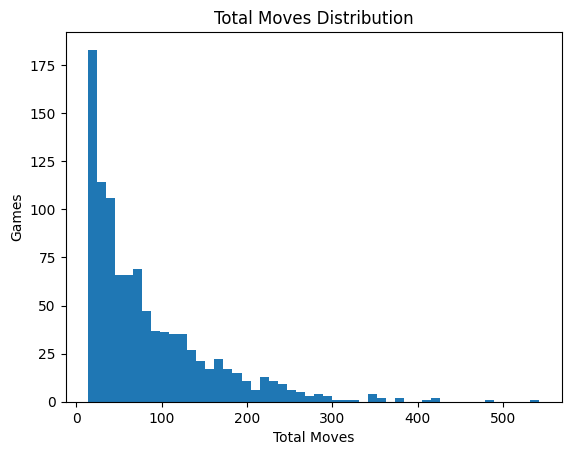

In [ ]:
plt.hist(sim_games_results_df["total_moves"], bins=50)
plt.title("Total Moves Distribution")
plt.xlabel("Total Moves")
plt.ylabel("Games")
plt.show()

In [ ]:
print(sim_games_results_df.groupby("winner")["total_moves"].quantile([0.25, 0.5, 0.75, 0.9, 0.99]))

winner          
Aggressive  0.25     29.25
            0.50     58.50
            0.75    118.75
            0.90    193.90
            0.99    332.99
Cautious    0.25     33.00
            0.50     66.00
            0.75    121.00
            0.90    192.40
            0.99    349.98
Random      0.25     29.00
            0.50     59.00
            0.75    105.00
            0.90    166.00
            0.99    283.05
Name: total_moves, dtype: float64


In [ ]:
sim_games_results_df.groupby("winner").agg(
    total_moves_median=pd.NamedAgg(column="total_moves", aggfunc="median"),
    total_moves_qcd=pd.NamedAgg(column="total_moves", aggfunc=lambda x: (x.quantile(0.75) - x.quantile(0.25)) / (x.quantile(0.75) + x.quantile(0.25))),
)

,total_moves_median,total_moves_qcd
winner,,
Aggressive,58.5,0.604730
Cautious,66.0,0.571429
Random,59.0,0.567164


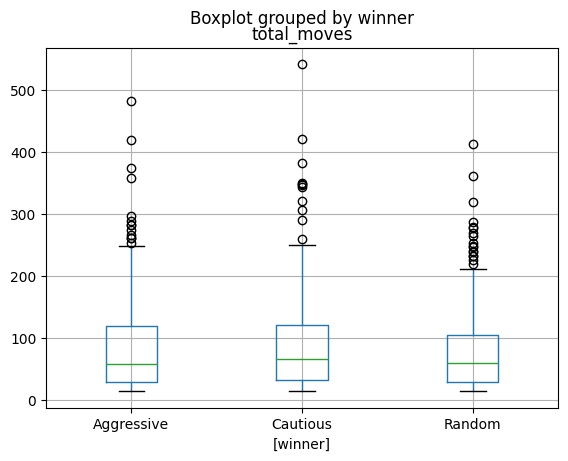

In [ ]:
sim_games_results_df[["total_moves", "winner"]].boxplot(by="winner")
plt.show()

## winrate per strategy

In [ ]:
sim_group_winners = sim_games_results_df.groupby("winner").agg(
    n_wins=pd.NamedAgg(column="game_id", aggfunc=lambda x: x.count()),
)
sim_group_winners["winrate"] = sim_group_winners["n_wins"] / len(sim_games_results_df)
sim_group_winners

,n_wins,winrate
winner,,
Aggressive,342,0.342
Cautious,302,0.302
Random,356,0.356


<Axes: xlabel='winner'>

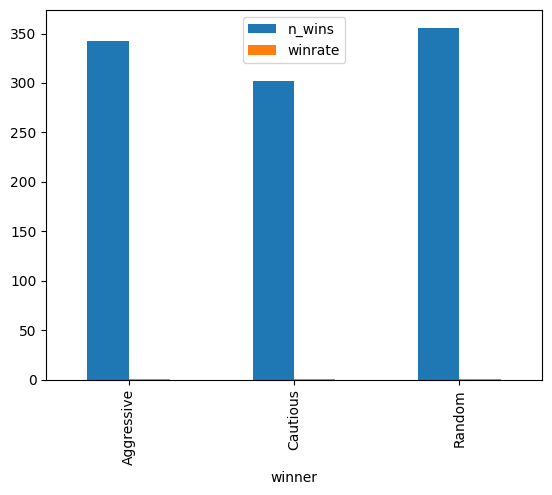

In [ ]:
sim_group_winners.plot.bar()

In [ ]:
n_wins_list = sim_group_winners["n_wins"].to_list()
statistic, p_value = stats.chisquare(n_wins_list)

print(f"Chi2 statistic: {statistic:.4f}")
print(f"p-value: {p_value:.4f}")


Chi2 statistic: 4.7120
p-value: 0.0948


## most popular action made

In [ ]:
sim_games_data_df["action_made.action"].value_counts()

action_made.action
play_card                            19894
draw_card                            18414
war                                   9492
skipped_turn_because_of_block         5869
execute_war                           5592
skip                                  4701
block                                 3619
suit_demand                           3198
value_demand                          3163
execute_block                         2446
draw_card_because_dont_have_value     2212
draw_card_because_dont_have_suit      1835
play_demanded_suit                    1516
play_demanded_value                   1403
Name: count, dtype: int64

## most popular card to play

In [ ]:
sim_games_data_df["action_made.card"].value_counts()

[1226,
 1167,
 1164,
 1144,
 995,
 989,
 984,
 977,
 974,
 968,
 967,
 953,
 914,
 913,
 912,
 912,
 907,
 904,
 903,
 902,
 901,
 893,
 891,
 888,
 887,
 887,
 885,
 883,
 882,
 881,
 880,
 878,
 877,
 877,
 874,
 871,
 865,
 862,
 847,
 841,
 838,
 838,
 830,
 816,
 803,
 803,
 800,
 796,
 794,
 783,
 781,
 779]

## TODO strategyA_vs_strategyB matrix/heatmap

## TODO correlation between total_moves and n_wins for all strategy

In [ ]:
sim_games_results_df['is_cautious_win'] = (sim_games_results_df['winner'] == 'Cautious').astype(int)
sim_games_results_df['is_agg_win'] = (sim_games_results_df['winner'] == 'Aggressive').astype(int)
sim_games_results_df['is_random_win'] = (sim_games_results_df['winner'] == 'Random').astype(int)

In [ ]:
total_moves_list = sim_games_results_df["total_moves"].to_list()
caut_wins = sim_games_results_df["is_cautious_win"].to_list()
agg_wins = sim_games_results_df["is_agg_win"].to_list()
rand_wins = sim_games_results_df["is_random_win"].to_list()

caut_res = stats.pointbiserialr(caut_wins, total_moves_list)
agg_res = stats.pointbiserialr(agg_wins, total_moves_list)
rand_res = stats.pointbiserialr(rand_wins, total_moves_list)

,game_id,winner,total_moves,is_cautious_win,is_agg_win,is_random_win
0,0,Aggressive,23,0,0,0
1,1,Random,28,0,0,1
2,2,Random,247,0,0,1
3,3,Random,41,0,0,1
4,4,Random,43,0,0,1
...,...,...,...,...,...,...
995,995,Cautious,223,1,0,0
996,996,Cautious,73,1,0,0
997,997,Aggressive,262,0,0,0
998,998,Cautious,218,1,0,0


In [ ]:
print(f"Korelacja: {caut_res.correlation:.3f}")
print(f"Wartość p: {caut_res.pvalue:.4f}")

print(f"Korelacja: {agg_res.correlation:.3f}")
print(f"Wartość p: {agg_res.pvalue:.4f}")

print(f"Korelacja: {rand_res.correlation:.3f}")
print(f"Wartość p: {rand_res.pvalue:.4f}")